## Setup and Imports

In [ ]:
! pip install diptest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.4/197.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, convolve2d
from tqdm import tqdm
import diptest

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cscale = ["#B78D64", "#A4B161", "#3F6871", "#764177","#754C24", '#657123','#4A184C','#183F48']

# Functions


In [ ]:
def find_qpp(data,T):

  '''
  Given a timeseries data and a qpp template this function calculates
  Quasi-Periodic Pattens defined in this paper: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10557593/

  Data can be in any modality and scale,
  QPP template can have any lenght, and its lenght will determine the lenght of the returned qpp convolution timeseries

  Arguments:
    data {ndarray} -- 2d numpy array of shape (# of features/channels/voxels, # of timepoints) that stores timeseries data
    T {ndarray} -- 2d numpy array of shape (# of features/channels/voxels, # of timepoints in QPP window) that stores the initially inputed QPP pattern.
  Returns:
    qpp {ndarray} -- 2d numpy array of shape (# of features/channels/voxels, # of timepoints in QPP window) that stores the resulting QPP pattern.
    cn {ndarray} -- 1d numpy array of shape (# of timepoints - qpp template window size)
        stores the final convolution timeseries i.e. the qpp similarity timeseries. It is the normalized version of the template convolution timeseries

  '''
  qpp_window_size = T.shape[1]
  ns = data.shape[1]- qpp_window_size # ns  is the number of extractable windows in the data
  nX = data.shape[0] # nX is the number of timepoints in the data

  # initialize a random qpp similarity timeseries to compare with the for the first iteration of the loop.
  # there probably is a more graceful way to do this, show me how please
  # also c is the 1d numpy array that stores the convolution timeseries i.e. the qpp similarity timeseries
  initial_random_c = np.random.rand(convolve2d(data, np.flip(T), mode='valid')[0].shape[0])
  last_c = initial_random_c

  # set the qpp pattern variable to the one inputted
  new_pattern = T

  # initialize a tqdm progress bar
  pbar = tqdm()

  qpp_similarity_to_last = 0
  # while the difference between the last and the current qpp convolution timeseries is smaller than 0.9999
  while qpp_similarity_to_last < 0.9999:

    # create the convolution timeseries
    flipped_T = np.flip(new_pattern)
    c = convolve2d(data, flipped_T, mode='valid')[0]

    # normalize the convolution timeseries
    c_mean = np.mean(c)
    c_std = np.std(c)
    cn = (c - c_mean) / c_std

    # find peaks to use as indices to create a new avearge qpp pattern
    peaks, _ = find_peaks(cn)

    # update the qpp pattern based on peaks
    # instead of starting from zeros, could also directly add to the current qpp template
    # by commenting the line below:
    new_pattern = np.zeros_like(T)

    for peak in peaks:
      if (peak+qpp_window_size) <= data.shape[1]:
        peak_pattern = data[:,peak:peak+qpp_window_size]
        new_pattern += peak_pattern
    new_pattern = new_pattern/peaks.shape[0]

    # normalize the new pattern
    normalized_new_pattern = zscore(new_pattern,axis=0) # over voxels axis
    new_pattern = normalized_new_pattern

    # update the progress bar
    pbar.update(1)

    # update the while loop variables
    qpp_similarity_to_last = np.corrcoef(cn, last_c)[0][1]
    last_c = cn
    qpp = new_pattern
    '''
    Should you want to, you can plot a summary figure for each iteration for exploration/troubleshooting

    fig, axs = plt.subplots(1,3,figsize=(5,2),width_ratios=(3,1,1))

    axs[0].imshow(data,aspect='auto')
    axs[0].axvline(x=random_starting_point,c='red')
    axs[0].axvline(x=random_starting_point+npt,c='red')

    axs[1].imshow(T)
    axs[2].imshow(new_pattern)
    '''
  pbar.close()
  return qpp, cn

In [ ]:
# @title
from sklearn.decomposition import PCA
from scipy.stats import zscore

def make_rotation_template(data_array):
    '''
    Takes a 2d (#of timepoints, #of features) data array and creates a template by:
    finding the timepoint that is most similar to every other,
    finding timepoints that are similar to the most similar one above some threshold,
    finding timepoints that are dissimilar to the most similar one below some threshold (orthogonal),
    averaging the similar timpoints and inverse of negatively similar timepoints (*-1)

    returns 1d (#of features) template pattern
    '''

    tr_corr_mtx = np.corrcoef(data_array)

    tr_scores = np.zeros((tr_corr_mtx.shape[0]))
    for count, tr in enumerate(tr_corr_mtx):
        tr_score = np.sum(np.absolute(tr))
        tr_scores[count] = tr_score/tr.shape[0]

    most_similar_idx = np.argmax(tr_scores)

    similarity_to_tr_template = []
    for tr_pattern in data_array:
        similarity = np.corrcoef(tr_pattern,data_array[most_similar_idx])[0][1]
        similarity_to_tr_template.append(similarity)

    similarity_to_tr_template = np.array(similarity_to_tr_template)

    if np.corrcoef(similarity_to_tr_template,np.mean(data_array,axis=1))[0][1] > 0:
        positive_template_tr_indices = np.where(similarity_to_tr_template>0)[0]
        negative_template_tr_indices = np.where(similarity_to_tr_template<0)[0]
    else:
        positive_template_tr_indices = np.where(similarity_to_tr_template<0)[0]
        negative_template_tr_indices = np.where(similarity_to_tr_template>0)[0]

    positive_tr_template = np.mean(data_array[positive_template_tr_indices],axis=0)
    negative_tr_template = np.nanmean(data_array[negative_template_tr_indices],axis=0)*-1

    average_tr_template = np.mean([positive_tr_template,negative_tr_template],axis=0)

    return average_tr_template, positive_template_tr_indices, negative_template_tr_indices

def create_template_correlation_timeseries(template, data_array):
    '''
    Takes in:
    template: 1d array of length (#of features)
    data_array: 2d array of shape (#of timepoints, #of features)
    Outputs:
    template similarity timeseries: 1d array of length (#of timepoints)
    '''
    template_similarity_timeseries = []

    for tr_pattern in data_array:

        similarity = np.corrcoef(tr_pattern,template)[0][1]
        template_similarity_timeseries.append(similarity)

    template_similarity_timeseries = np.array(template_similarity_timeseries)

    return template_similarity_timeseries

In [ ]:
def run_diptest(data):
  '''
  Arguments
  - Data: 2d multivariate timeseries of shape (n_features,n_timepoints)
  Returns
  - dips:
  - dip_pvals:
  '''

  TbyT_corr = np.corrcoef(data.T)
  meta_TbyT_corr = np.corrcoef(TbyT_corr)
  n_timepoints = len(meta_TbyT_corr)

  dips, dip_pvals = [], []
  for i in range(n_timepoints):
    dip, pval = diptest.diptest(meta_TbyT_corr[i,:].flatten())
    dips.append(dip)
    dip_pvals.append(pval)

  dips, dip_pvals = np.asarray(dips), np.asarray(dip_pvals)
  return dips, dip_pvals

def template_creation(data, with_dip=True):
    if with_dip:
      dips, dip_pvals = run_diptest(data)
      template_data = data[:,dip_pvals<.05]
    else:
      template_data = data

    template_mean = np.mean(template_data, axis=1)
    template_data = template_data - template_mean[:,None]

    template_correlations = np.corrcoef(template_data.T)
    correlation_signs = np.sign(template_correlations[:,0])

    # # Scaling all vectors to the same length
    # template_data = template_data / np.linalg.norm(template_data, axis=0)

    template = np.mean(template_data*correlation_signs[None,:], axis=1)

    template_timeseries, template_timeseries_projection = template_projection(template_mean, template, template_data)

    if np.corrcoef(np.mean(template_data,axis=0), template_timeseries_projection)[0][1]<0:
      template = template*-1

    return template_mean, template

def template_projection(template_mean, template, data):
    template_timeseries_projection = data - template_mean[:,None]

    # Projecting the template vector on to the roi signal
    # 1) measure the dot product
    template_timeseries_projection = (np.einsum('in,i->n', template_timeseries_projection, template))
    # 2) Divide the dot product by the square magnitude of the template vec
    template_timeseries_projection = template_timeseries_projection / (np.linalg.norm(template, ord=2)**2)

    template_timeseries = template_mean[:,None] + template[:, None] * template_timeseries_projection

    return template_timeseries, template_timeseries_projection

# QPP and Anti-Correlated Template Comparison

This data is hyperaligned group averaged and has a tr of 2 seconds.
It comes from the firts run of the studyforrest 3T movie-viewing dataset.

### Load Local ROI Data

In [ ]:
brain_data = np.load('/content/drive/My Drive/FPN_Workshop/run-1_VIS_L_mean.npy')
brain_data = brain_data.T

npt = 12 # number of template timepoints, qpp template window size
nT = brain_data.shape[1] # number of total timepoints


#### Find QPP

In [ ]:
# example starting template from the data
random_starting_point = np.random.randint(0,nT-npt)
print('Started with initial qpp at: ',random_starting_point)
T = brain_data[:,random_starting_point:random_starting_point+npt]

qpp_pattern, cn = find_qpp(brain_data,T)

peaks, _ = find_peaks(cn)

Started with initial qpp at:  247


17it [00:00, 366.46it/s]


Text(0, 0.5, 'Voxel')

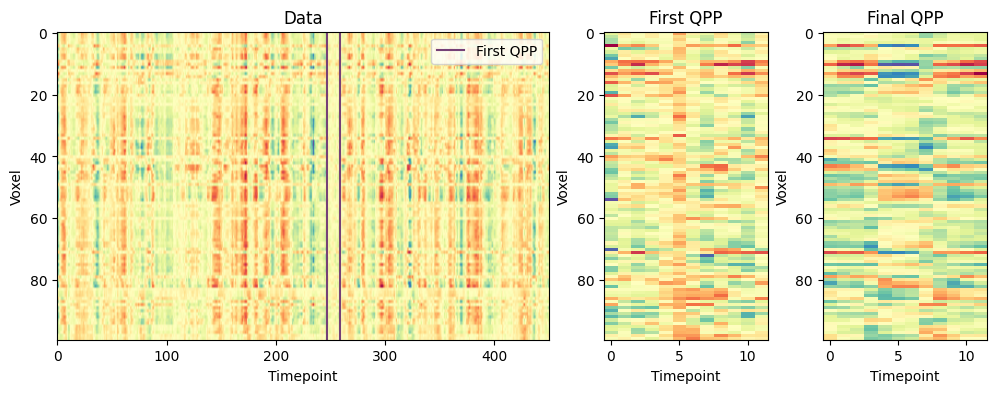

In [ ]:
# @title
fig, axs = plt.subplots(1,3,figsize=(12,4),width_ratios=(3,1,1))

axs[0].set_title('Data')
axs[0].imshow(brain_data,aspect='auto',cmap='Spectral_r')
axs[0].axvline(x=random_starting_point,c=cscale[3],label='First QPP')
axs[0].axvline(x=random_starting_point+npt,c=cscale[3])
axs[0].set_xlabel('Timepoint')
axs[0].set_ylabel('Voxel')
axs[0].legend()

axs[1].set_title('First QPP')
axs[1].imshow(T,aspect='auto',cmap='Spectral_r')
axs[1].set_xlabel('Timepoint')
axs[1].set_ylabel('Voxel')


axs[2].set_title('Final QPP')
axs[2].imshow(qpp_pattern,aspect='auto',cmap='Spectral_r')
axs[2].set_xlabel('Timepoint')
axs[2].set_ylabel('Voxel')


#### Find anti-correlatd template

In [ ]:
template_mean, average_tr_template= template_creation(brain_data, with_dip=True)
template_timeseries, template_similarity_timeseries = template_projection(template_mean, average_tr_template, brain_data)

#### Comparison

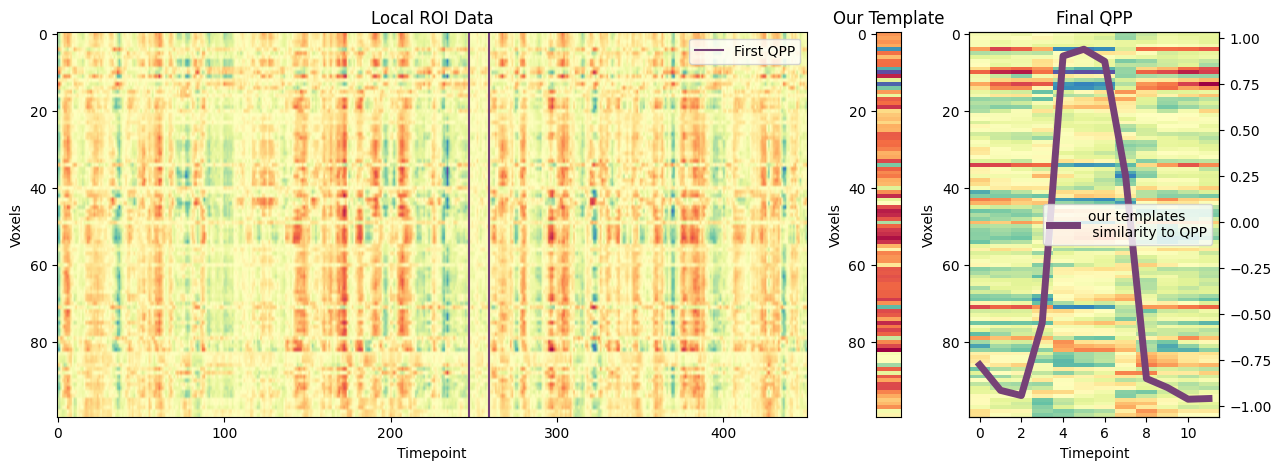

In [ ]:
# @title
template_similarity_to_qpp = []
for timepoint in qpp_pattern.T:
  template_similarity_to_qpp.append(np.corrcoef(timepoint,average_tr_template)[0][1])

fig, axs = plt.subplots(1,3,figsize=(15,5),width_ratios=(3,.1,1))

axs[0].set_title('Local ROI Data')
axs[0].imshow(brain_data,aspect='auto',cmap='Spectral_r')
axs[0].axvline(x=random_starting_point,c=cscale[3],label='First QPP')
axs[0].axvline(x=random_starting_point+npt,c=cscale[3])
axs[0].set_xlabel('Timepoint')
axs[0].set_ylabel('Voxels')
axs[0].legend()

axs[1].set_title('Our Template')
axs[1].imshow(np.expand_dims(average_tr_template, axis=1),aspect='auto',cmap='Spectral_r')
axs[1].axes.xaxis.set_ticklabels([])
axs[1].axes.xaxis.set_ticks([])
axs[1].set_ylabel('Voxels')

axs[2].set_title('Final QPP')
axs[2].imshow(qpp_pattern,aspect='auto',cmap='Spectral_r')
axs[2].set_xlabel('Timepoint')
axs[2].set_ylabel('Voxels')

axs1=axs[2].twinx()
axs1.plot(template_similarity_to_qpp,c=cscale[3],label='our templates \n similarity to QPP',linewidth=5)
axs1.legend()

### Load Global Whole-Brain Data

In [ ]:
# Assume data_np is your NumPy array of shape (n_features, n_samples)
data_np = np.load('/content/drive/My Drive/studyforrest_whole_brain_mean_concat_data.npy',allow_pickle=True)

# Transpose data to shape (n_samples, n_features)
data_np = data_np.T[:451].T

#### Find QPP

In [ ]:
npt = 10 # number of template timepoints, qpp template window size
nT = data_np.shape[1] # number of total timepoints

# example starting template from the data
random_starting_point = np.random.randint(0,nT-npt)
print('Started with initial qpp at: ',random_starting_point)
T = data_np[:,random_starting_point:random_starting_point+npt]

qpp_pattern, cn = find_qpp(data_np,T)

peaks, _ = find_peaks(cn)

Started with initial qpp at:  303


7it [00:00, 10.62it/s]


#### Find anti-correlatd template

In [ ]:
template_mean, average_tr_template= template_creation(data_np, with_dip=True)
template_timeseries, template_similarity_timeseries = template_projection(template_mean, average_tr_template, data_np)

#### Comparison

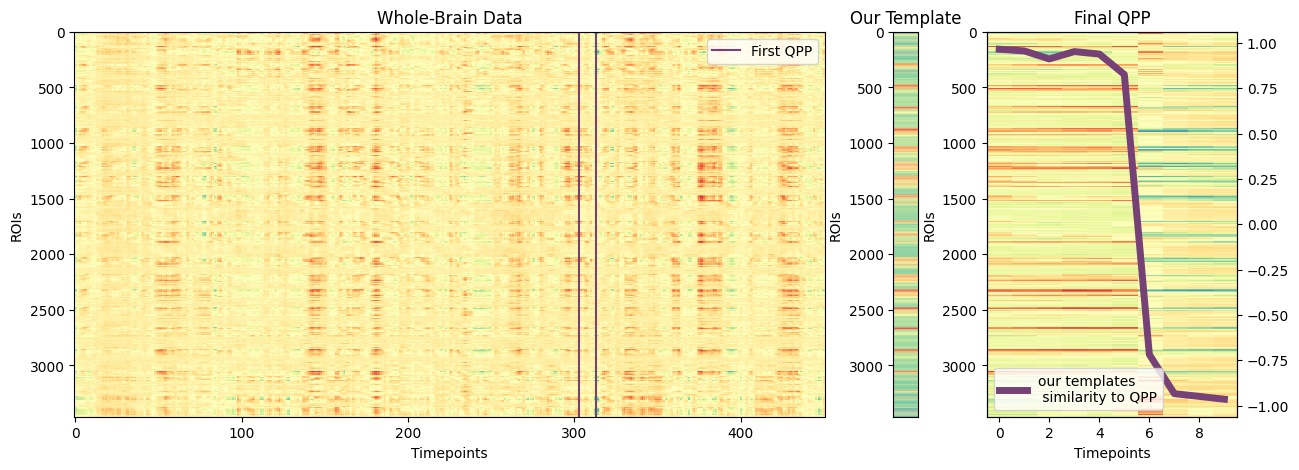

In [ ]:
# @title
template_similarity_to_qpp = []
for timepoint in qpp_pattern.T:
  template_similarity_to_qpp.append(np.corrcoef(timepoint,average_tr_template)[0][1])

fig, axs = plt.subplots(1,3,figsize=(15,5),width_ratios=(3,.1,1))

axs[0].set_title('Whole-Brain Data')
axs[0].imshow(data_np,aspect='auto',interpolation='none',cmap='Spectral_r')
axs[0].axvline(x=random_starting_point,c=cscale[3],label='First QPP')
axs[0].axvline(x=random_starting_point+npt,c=cscale[3])
axs[0].set_xlabel('Timepoints')
axs[0].set_ylabel('ROIs')
axs[0].legend()

axs[1].set_title('Our Template')
axs[1].imshow(np.expand_dims(average_tr_template, axis=1),aspect='auto',cmap='Spectral_r')
axs[1].axes.xaxis.set_ticklabels([])
axs[1].axes.xaxis.set_ticks([])
axs[1].set_ylabel('ROIs')


axs[2].set_title('Final QPP')
axs[2].imshow(qpp_pattern,aspect='auto',interpolation='none',cmap='Spectral_r')
axs[2].set_ylabel('ROIs')
axs[2].set_xlabel('Timepoints')
axs1=axs[2].twinx()
axs1.plot(template_similarity_to_qpp,c=cscale[3],label='our templates \n similarity to QPP',linewidth=5)
axs1.legend()